# Deepfake Detection - Local Version

> Add blockquote

> Add blockquote

### content of folder
```

your_project_folder/
├── deepfake_detection_local.ipynb   ← notebook
├── dataset_100/
│   ├── real/
│   ├── Deepfakes/
│   ├── Face2Face/
│   ├── FaceSwap/
│   └── NeuralTextures/
├── train.json
├── val.json
└── test.json
```

### Changes for Local Windows Execution
Change	Reason
BASE_DIR = os.getcwd()	Automatically sets paths based on the notebook location
num_workers = 0	Windows does not fully support multiprocessing in DataLoader
batch_size = 16	Reduces RAM usage when running on CPU
do_download = False	Dataset is already available locally
skip_extract = True	Frames are already extracted


# Deepfake Detection - Binary Baseline (Official FF++ Split)

This notebook uses the **official FaceForensics++ split files** (`train.json`, `val.json`, `test.json`) at the pair level.

### Key protocol choices
- **CPU-only** baseline
- **real = 0**, **fake = 1**
- **Official split** by pair membership (`<target>_<source>`)
- **Real videos** assigned using the original IDs appearing in each split file
- **WeightedRandomSampler** for balanced training
- **Threshold tuning** on validation
- **Frame-level** and **group-level** evaluation

In [ ]:
import os, json, random, shutil, subprocess
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cpu')
print('DEVICE:', DEVICE)


DEVICE: cpu


In [ ]:
import os
# BASE_DIR = notebook
BASE_DIR = os.getcwd()

@dataclass
class CFG:
    # Paths — relative to notebook folder
    root_dir: str = r'C:\Users\DPQUAI250101\Desktop\deep_fake_version_3\FaceForensics_300\content\FaceForensics_300'
    work_dir:    str = BASE_DIR
    dataset_dir: str = os.path.join(BASE_DIR, 'dataset_300')
    index_csv:   str = os.path.join(BASE_DIR, 'final_officialsplit_index_1.csv')
    best_ckpt:   str = os.path.join(BASE_DIR, 'best_model_officialsplit_1.pth')

    # Split JSONs
    split_train_json: str = os.path.join(BASE_DIR, 'train.json')
    split_val_json:   str = os.path.join(BASE_DIR, 'val.json')
    split_test_json:  str = os.path.join(BASE_DIR, 'test.json')

    # Dataset
    compression:           str  = 'c23'
    max_videos_per_folder: int  = 300
    frames_per_video:      int  = 20
    image_size:            int  = 224

    # Download / Extract
    do_download:  bool = False
    skip_extract: bool = True

    download_script_url: str = 'https://kaldir.vc.in.tum.de/faceforensics_download_v4.py'
    server: str = 'EU2'

    # Training
    batch_size:    int   = 16
    num_workers:   int   = 0
    stage1_epochs: int   = 5
    stage2_epochs: int   = 15
    patience:      int   = 4
    stage1_lr:     float = 1e-3
    stage2_lr:     float = 1e-5
    weight_decay:  float = 1e-4
    label_smoothing: float = 0.05
    use_weighted_sampler: bool = True
    threshold_grid: int  = 39

cfg = CFG()
print("BASE_DIR:", BASE_DIR)
print("dataset_dir:", cfg.dataset_dir)
print("Config ready")


BASE_DIR: c:\Users\DPQUAI250101\Desktop\New folder (4)
dataset_dir: c:\Users\DPQUAI250101\Desktop\New folder (4)\dataset_300
Config ready


In [ ]:
SPLIT_FILES = {
    'train': cfg.split_train_json,
    'val': cfg.split_val_json,
    'test': cfg.split_test_json,
}

def load_official_splits():
    split_pairs = {}
    for split_name, fp in SPLIT_FILES.items():
        data = json.loads(Path(fp).read_text())
        pair_keys = set()
        ids = set()
        for a, b in data:
            pair_keys.add(f'{a}_{b}')
            ids.add(a)
            ids.add(b)
        split_pairs[split_name] = {'pairs': pair_keys, 'ids': ids}
    return split_pairs

official_splits = load_official_splits()
print('Train pairs:', len(official_splits['train']['pairs']))
print('Val pairs:', len(official_splits['val']['pairs']))
print('Test pairs:', len(official_splits['test']['pairs']))
print('Sample train pairs:', list(sorted(official_splits['train']['pairs']))[:5])

# overlap sanity check
print('train∩val pairs:', len(official_splits['train']['pairs'] & official_splits['val']['pairs']))
print('train∩test pairs:', len(official_splits['train']['pairs'] & official_splits['test']['pairs']))
print('val∩test pairs:', len(official_splits['val']['pairs'] & official_splits['test']['pairs']))


Train pairs: 360
Val pairs: 70
Test pairs: 70
Sample train pairs: ['005_010', '006_002', '007_132', '011_805', '013_883']
train∩val pairs: 0
train∩test pairs: 0
val∩test pairs: 0


In [ ]:
def run(cmd, check=True):
    print('>>', ' '.join(cmd))
    return subprocess.run(cmd, check=check)

def ensure_download_script():
    dst = Path(cfg.work_dir) / 'download.py'
    if dst.exists():
        return str(dst)
    run(['wget', '-O', str(dst), cfg.download_script_url, '--no-check-certificate'])
    return str(dst)

def download_videos():
    script = ensure_download_script()
    Path(cfg.root_dir).mkdir(parents=True, exist_ok=True)
    for d in ['original', 'Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures']:
        run(['bash', '-lc', f'echo "" | python {script} {cfg.root_dir} -d {d} -c {cfg.compression} -t videos -n {cfg.max_videos_per_folder} --server {cfg.server}'])

def list_mp4(folder):
    return sorted([p for p in Path(folder).glob('*.mp4')])

def sanity_check_videos():
    root = Path(cfg.root_dir)
    paths = {
        'real': root / f'original_sequences/youtube/{cfg.compression}/videos',
        'Deepfakes': root / f'manipulated_sequences/Deepfakes/{cfg.compression}/videos',
        'Face2Face': root / f'manipulated_sequences/Face2Face/{cfg.compression}/videos',
        'FaceSwap': root / f'manipulated_sequences/FaceSwap/{cfg.compression}/videos',
        'NeuralTextures': root / f'manipulated_sequences/NeuralTextures/{cfg.compression}/videos',
    }
    for k,p in paths.items():
        vids = list_mp4(str(p))
        print(f'{k}: {len(vids)} videos | sample: {[v.name for v in vids[:3]]}')

if cfg.do_download:
    download_videos()

sanity_check_videos()


real: 300 videos | sample: ['004.mp4', '008.mp4', '009.mp4']
Deepfakes: 300 videos | sample: ['004_982.mp4', '008_990.mp4', '009_027.mp4']
Face2Face: 300 videos | sample: ['004_982.mp4', '008_990.mp4', '009_027.mp4']
FaceSwap: 300 videos | sample: ['004_982.mp4', '008_990.mp4', '009_027.mp4']
NeuralTextures: 300 videos | sample: ['004_982.mp4', '008_990.mp4', '009_027.mp4']


In [ ]:
def build_face_cascade():
    haar = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    return cv2.CascadeClassifier(haar)

def center_crop_square(img):
    h, w = img.shape[:2]
    m = min(h, w)
    y1 = (h-m)//2
    x1 = (w-m)//2
    return img[y1:y1+m, x1:x1+m]

def detect_face(frame, cascade, pad=0.40):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = cascade.detectMultiScale(gray, 1.1, 5, minSize=(60,60))
    if len(faces) == 0:
        return None
    x, y, w, h = sorted(faces, key=lambda b: b[2]*b[3], reverse=True)[0]
    cx, cy = x + w/2, y + h/2
    side = max(w, h) * (1 + pad)
    x1 = int(max(0, cx - side/2)); y1 = int(max(0, cy - side/2))
    x2 = int(min(frame.shape[1], cx + side/2)); y2 = int(min(frame.shape[0], cy + side/2))
    crop = frame[y1:y2, x1:x2]
    return crop if crop.size > 0 else None

def extract_frames(video_dir, out_dir):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    videos = sorted(Path(video_dir).glob('*.mp4'))[:cfg.max_videos_per_folder]
    cascade = build_face_cascade()
    total = 0
    for vp in videos:
        cap = cv2.VideoCapture(str(vp))
        n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if n <= 0:
            cap.release(); continue
        step = max(1, n // cfg.frames_per_video)
        base = vp.stem
        for i in range(cfg.frames_per_video):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
            ok, frame = cap.read()
            if not ok:
                continue
            crop = detect_face(frame, cascade)
            if crop is None:
                crop = center_crop_square(frame)
            crop = cv2.resize(crop, (cfg.image_size, cfg.image_size))
            out_path = Path(out_dir) / f'{base}_frame{i:02d}.jpg'
            cv2.imwrite(str(out_path), crop)
            total += 1
        cap.release()
    print(f'{out_dir} -> {total} frames')

def extract_all_frames():
    out_root = Path(cfg.dataset_dir)
    out_root.mkdir(parents=True, exist_ok=True)
    if cfg.skip_extract:
        existing = sum(1 for _ in out_root.rglob('*.jpg'))
        if existing > 0:
            print(f'Frames already exist: {existing} jpg files. Skipping extraction.')
            return
    root = Path(cfg.root_dir)
    extract_frames(str(root / f'original_sequences/youtube/{cfg.compression}/videos'), str(out_root / 'real'))
    for m in ['Deepfakes','Face2Face','FaceSwap','NeuralTextures']:
        extract_frames(str(root / f'manipulated_sequences/{m}/{cfg.compression}/videos'), str(out_root / m))

extract_all_frames()

Frames already exist: 30000 jpg files. Skipping extraction.


In [ ]:
def video_id_from_name(fname):
    return fname.split('_frame')[0]

def build_index_official():
    data_root = Path(cfg.dataset_dir)
    rows = []
    classes = sorted([d.name for d in data_root.iterdir() if d.is_dir()])
    for cls in classes:
        cls_dir = data_root / cls
        for p in cls_dir.glob('*.jpg'):
            vid = video_id_from_name(p.name)
            bin_label = 'real' if cls == 'real' else 'fake'
            target = 0 if bin_label == 'real' else 1
            assigned_split = None
            if bin_label == 'fake':
                if vid in official_splits['train']['pairs']:
                    assigned_split = 'train'
                elif vid in official_splits['val']['pairs']:
                    assigned_split = 'val'
                elif vid in official_splits['test']['pairs']:
                    assigned_split = 'test'
            else:
                if vid in official_splits['train']['ids']:
                    assigned_split = 'train'
                elif vid in official_splits['val']['ids']:
                    assigned_split = 'val'
                elif vid in official_splits['test']['ids']:
                    assigned_split = 'test'
            if assigned_split is None:
                continue
            rows.append({
                'path': str(p),
                'label': cls,
                'video_id': vid,
                'bin_label': bin_label,
                'target': target,
                'split_group': vid,
                'video_uid': f'{cls}::{vid}',
                'split': assigned_split,
            })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError('No frames matched the official split. Check split files and extraction.')
    df.to_csv(cfg.index_csv, index=False)
    print('Saved index:', cfg.index_csv)
    print('Frame counts by split/class:')
    print(df.groupby(['split','bin_label']).size())
    print('Unique groups by split/class:')
    print(df.groupby(['split','bin_label'])['split_group'].nunique())
    return df

df = build_index_official()

# Sanity checks
train_groups = set(df[df.split == 'train']['split_group'].unique())
val_groups = set(df[df.split == 'val']['split_group'].unique())
test_groups = set(df[df.split == 'test']['split_group'].unique())
print('train ∩ val :', len(train_groups & val_groups))
print('train ∩ test:', len(train_groups & test_groups))
print('val ∩ test  :', len(val_groups & test_groups))

Saved index: c:\Users\DPQUAI250101\Desktop\New folder (4)\final_officialsplit_index_1.csv
Frame counts by split/class:
split  bin_label
test   fake         1840
       real          920
train  fake         8080
       real         4040
val    fake         2080
       real         1040
dtype: int64
Unique groups by split/class:
split  bin_label
test   fake          23
       real          46
train  fake         101
       real         202
val    fake          26
       real          52
Name: split_group, dtype: int64
train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0


In [ ]:
class FFPPDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        label = int(row['target'])
        if self.transform:
            img = self.transform(img)
        return img, label

def make_loaders(df):
    train_tf = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    test_tf = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    train_df = df[df.split == 'train'].copy()
    val_df = df[df.split == 'val'].copy()
    test_df = df[df.split == 'test'].copy()
    train_ds = FFPPDataset(train_df, train_tf)
    val_ds = FFPPDataset(val_df, test_tf)
    test_ds = FFPPDataset(test_df, test_tf)
    if cfg.use_weighted_sampler:
        labels = train_df['target'].values
        counts = np.bincount(labels, minlength=2)
        class_weights = 1.0 / np.maximum(counts, 1)
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, sampler=sampler, num_workers=cfg.num_workers)
    else:
        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
    print('Val distribution:')
    print(val_df['bin_label'].value_counts())
    return train_loader, val_loader, test_loader, val_df, test_df, test_tf

train_loader, val_loader, test_loader, val_df, test_df, test_tf = make_loaders(df)


Train: 12120 | Val: 3120 | Test: 2760
Val distribution:
bin_label
fake    2080
real    1040
Name: count, dtype: int64


In [ ]:
def build_model():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    for p in model.features.parameters():
        p.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.last_channel, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 2),
    )
    model.to(DEVICE)
    return model

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss = 0.0
    preds, trues, prob_fake_list = [], [], []
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            pred = out.argmax(1)
            preds += pred.detach().cpu().numpy().tolist()
            trues += y.detach().cpu().numpy().tolist()
            prob_fake = torch.softmax(out, dim=1)[:, 1]
            prob_fake_list += prob_fake.detach().cpu().numpy().tolist()
    acc = accuracy_score(trues, preds)
    mf1 = f1_score(trues, preds, average='macro')
    auc = roc_auc_score(trues, prob_fake_list) if len(set(trues)) == 2 else float('nan')
    return total_loss / len(loader.dataset), acc, mf1, auc, trues, preds, prob_fake_list

def tune_threshold(y_true, prob_fake, grid=39, metric='f1'):

    best_t, best_f1, best_acc, best_score = 0.5, -1.0, -1.0, -1.0
    for t in np.linspace(0.05, 0.95, grid):
        pred = (np.array(prob_fake) >= t).astype(int)
        mf1  = f1_score(y_true, pred, average='macro', zero_division=0)
        acc  = accuracy_score(y_true, pred)
        score = mf1 if metric == 'f1' else acc
        if score > best_score:
            best_t, best_f1, best_acc, best_score = float(t), mf1, acc, score
    return best_t, best_acc, best_f1

def collect_group_scores(model, df_split, transform):
    model.eval()
    group_scores, group_true = {}, {}
    with torch.no_grad():
        for _, row in df_split.iterrows():
            img = Image.open(row['path']).convert('RGB')
            x = transform(img).unsqueeze(0).to(DEVICE)
            out = model(x)
            prob_fake = torch.softmax(out, dim=1)[0, 1].cpu().item()
            g = row['split_group']
            group_scores.setdefault(g, []).append(prob_fake)
            group_true[g] = int(row['target'])
    y_true, y_score = [], []
    for g, scores in group_scores.items():
        y_true.append(group_true[g])
        y_score.append(float(np.mean(scores)))
    return np.array(y_true), np.array(y_score)

def eval_group_level(model, df_split, transform, threshold):
    y_true, y_score = collect_group_scores(model, df_split, transform)
    y_pred = (y_score >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, y_score) if len(set(y_true)) == 2 else float('nan')
    return acc, mf1, auc, len(y_true)

model = build_model()

class_w   = torch.tensor([4.0, 1.0], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=cfg.label_smoothing)
print('Model ready. Trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))

optimizer = optim.AdamW(model.classifier.parameters(), lr=cfg.stage1_lr, weight_decay=cfg.weight_decay)
print('=== Stage 1 ===')
for ep in range(cfg.stage1_epochs):
    tr = run_epoch(model, train_loader, criterion, optimizer)
    va = run_epoch(model, val_loader, criterion)
    print(f'[S1] Ep{ep+1}/{cfg.stage1_epochs} | Train acc {tr[1]*100:.1f}% f1 {tr[2]:.3f} auc {tr[3]:.3f} | Val acc {va[1]*100:.1f}% f1 {va[2]:.3f} auc {va[3]:.3f}')


for p in model.features[-4:].parameters():
    p.requires_grad = True
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.stage2_lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
best_f1, bad = -1.0, 0
print('=== Stage 2 ===')
for ep in range(cfg.stage2_epochs):
    tr = run_epoch(model, train_loader, criterion, optimizer)
    va = run_epoch(model, val_loader, criterion)
    scheduler.step(va[2])
    if va[2] > best_f1:
        best_f1 = va[2]
        bad = 0
        torch.save(model.state_dict(), cfg.best_ckpt)
    else:
        bad += 1
    print(f'[S2] Ep{ep+1:02d} | Train acc {tr[1]*100:.1f}% f1 {tr[2]:.3f} | Val acc {va[1]*100:.1f}% f1 {va[2]:.3f} auc {va[3]:.3f} | best {best_f1:.3f} bad {bad}/{cfg.patience}')
    if bad >= cfg.patience:
        print('Early stopping')
        break

model.load_state_dict(torch.load(cfg.best_ckpt, map_location=DEVICE))
va = run_epoch(model, val_loader, criterion)
y_val = np.array(va[4]); p_val = np.array(va[6])
best_t_acc, val_acc_tuned, val_f1_at_acc = tune_threshold(y_val, p_val, grid=cfg.threshold_grid, metric='accuracy')
best_t_f1, val_acc_at_f1, val_f1_tuned = tune_threshold(y_val, p_val, grid=cfg.threshold_grid, metric='f1')
print('Best threshold for Val Accuracy:', best_t_acc)
print('Val Accuracy:', val_acc_tuned)
print('Val Macro-F1:', val_f1_at_acc)
print('Best threshold for Val Macro-F1:', best_t_f1)
print('Val Accuracy:', val_acc_at_f1)
print('Val Macro-F1:', val_f1_tuned)

threshold = best_t_acc
te = run_epoch(model, test_loader, criterion)
y_test = np.array(te[4]); p_test = np.array(te[6])
pred_test = (p_test >= threshold).astype(int)
test_acc = accuracy_score(y_test, pred_test)
test_f1 = f1_score(y_test, pred_test, average='macro')
test_auc = roc_auc_score(y_test, p_test) if len(set(y_test)) == 2 else float('nan')
print('=== TEST RESULTS ===')
print(f'Accuracy: {test_acc*100:.2f}%')
print(f'Macro-F1: {test_f1:.3f}')
print(f'AUC: {test_auc:.3f}')

print('Confusion Matrix:\n', confusion_matrix(y_test, pred_test))
print(classification_report(y_test, pred_test, target_names=['real','fake']))

val_group = eval_group_level(model, val_df, test_tf, threshold)
test_group = eval_group_level(model, test_df, test_tf, threshold)
print('=== GROUP-LEVEL RESULTS ===')
print(f'VAL  acc {val_group[0]*100:.2f}% | f1 {val_group[1]:.3f} | auc {val_group[2]:.3f} | groups {val_group[3]}')
print(f'TEST acc {test_group[0]*100:.2f}% | f1 {test_group[1]:.3f} | auc {test_group[2]:.3f} | groups {test_group[3]}')

Model ready. Trainable params: 328450
=== Stage 1 ===
[S1] Ep1/5 | Train acc 52.8% f1 0.395 auc 0.693 | Val acc 38.0% f1 0.329 auc 0.729
[S1] Ep2/5 | Train acc 56.7% f1 0.476 auc 0.759 | Val acc 49.1% f1 0.483 auc 0.748
[S1] Ep3/5 | Train acc 59.3% f1 0.531 auc 0.796 | Val acc 41.9% f1 0.386 auc 0.748
[S1] Ep4/5 | Train acc 62.6% f1 0.570 auc 0.819 | Val acc 46.3% f1 0.447 auc 0.735
[S1] Ep5/5 | Train acc 63.1% f1 0.586 auc 0.832 | Val acc 51.7% f1 0.512 auc 0.755
=== Stage 2 ===
[S2] Ep01 | Train acc 66.5% f1 0.634 | Val acc 51.0% f1 0.502 auc 0.772 | best 0.502 bad 0/4
[S2] Ep02 | Train acc 69.0% f1 0.665 | Val acc 54.7% f1 0.544 auc 0.792 | best 0.544 bad 0/4
[S2] Ep03 | Train acc 72.6% f1 0.710 | Val acc 57.5% f1 0.574 auc 0.811 | best 0.574 bad 0/4
[S2] Ep04 | Train acc 74.2% f1 0.728 | Val acc 59.0% f1 0.590 auc 0.823 | best 0.590 bad 0/4
[S2] Ep05 | Train acc 76.4% f1 0.754 | Val acc 63.0% f1 0.630 auc 0.833 | best 0.630 bad 0/4
[S2] Ep06 | Train acc 78.4% f1 0.775 | Val acc 64.

In [ ]:
import io
import numpy as np
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch

def apply_jpeg_compression(img: Image.Image, quality: int) -> Image.Image:

    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).convert('RGB')

def apply_gaussian_noise(img: Image.Image, std: float) -> Image.Image:

    arr = np.array(img, dtype=np.float32)
    noise = np.random.randn(*arr.shape) * std
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def eval_robustness(model, df_split, transform, threshold, perturb_fn):

    model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for _, row in df_split.iterrows():
            img = Image.open(row['path']).convert('RGB')
            img = perturb_fn(img)
            x = transform(img).unsqueeze(0).to(DEVICE)
            out = model(x)
            prob_fake = torch.softmax(out, dim=1)[0, 1].cpu().item()
            pred = int(prob_fake >= threshold)
            probs.append(prob_fake)
            preds.append(pred)
            trues.append(int(row['target']))

    acc  = accuracy_score(trues, preds)
    mf1  = f1_score(trues, preds, average='macro')
    auc  = roc_auc_score(trues, probs) if len(set(trues)) == 2 else float('nan')
    return acc, mf1, auc



jpeg_qualities = [80, 60, 40, 20]
gaussian_stds  = [5, 10, 20, 40]

results = []

# Baseline
acc, mf1, auc = eval_robustness(
    model, test_df, test_tf, threshold,
    perturb_fn=lambda img: img
)
results.append({'perturbation': 'None (baseline)', 'param': '-', 'acc': acc, 'f1': mf1, 'auc': auc})
print(f"{'Perturbation':<30} {'Param':<8} {'Acc':>7} {'F1':>7} {'AUC':>7}")
print('-' * 65)
print(f"{'None (baseline)':<30} {'-':<8} {acc*100:>6.2f}% {mf1:>7.3f} {auc:>7.3f}")

# JPEG Compression
for q in jpeg_qualities:
    acc, mf1, auc = eval_robustness(
        model, test_df, test_tf, threshold,
        perturb_fn=lambda img, q=q: apply_jpeg_compression(img, q)
    )
    results.append({'perturbation': 'JPEG Compression', 'param': f'q={q}', 'acc': acc, 'f1': mf1, 'auc': auc})
    print(f"{'JPEG Compression':<30} {f'q={q}':<8} {acc*100:>6.2f}% {mf1:>7.3f} {auc:>7.3f}")

# Gaussian Noise
for s in gaussian_stds:
    acc, mf1, auc = eval_robustness(
        model, test_df, test_tf, threshold,
        perturb_fn=lambda img, s=s: apply_gaussian_noise(img, s)
    )
    results.append({'perturbation': 'Gaussian Noise', 'param': f'std={s}', 'acc': acc, 'f1': mf1, 'auc': auc})
    print(f"{'Gaussian Noise':<30} {f'std={s}':<8} {acc*100:>6.2f}% {mf1:>7.3f} {auc:>7.3f}")

import pandas as pd
rob_df = pd.DataFrame(results)
rob_csv = os.path.join(BASE_DIR, 'robustness_results.csv')
rob_df.to_csv(rob_csv, index=False)
print(f'\the result is saved: {rob_csv}')

Perturbation                   Param        Acc      F1     AUC
-----------------------------------------------------------------
None (baseline)                -         73.70%   0.710   0.812
JPEG Compression               q=80      58.41%   0.583   0.732
JPEG Compression               q=60      47.21%   0.462   0.666
JPEG Compression               q=40      47.25%   0.464   0.638
JPEG Compression               q=20      45.47%   0.450   0.597
Gaussian Noise                 std=5     67.54%   0.455   0.644
Gaussian Noise                 std=10    64.20%   0.497   0.563
Gaussian Noise                 std=20    64.71%   0.513   0.540
Gaussian Noise                 std=40    66.92%   0.431   0.512
	he result is saved: c:\Users\DPQUAI250101\Desktop\New folder (4)\robustness_results.csv


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np
from PIL import Image


def build_model_v1():
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    m.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(m.last_channel, 2),
    )
    m.to(DEVICE)
    return m

def build_model_v2():
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    m.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(m.last_channel, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 2),
    )
    m.to(DEVICE)
    return m

# Load v1 (simple head)
# ABLATION NOTE: V1 was trained on ~100 videos/method (FaceForensics_50_videos)
# while V2 was trained on ~300 videos/method (dataset_300).
# This comparison reflects the combined effect of architecture + data size.
# To isolate architecture alone, retrain V1 on dataset_300.
# Current framing: "Effect of deeper head + larger dataset combined."
model_v1 = build_model_v1()
model_v1.load_state_dict(torch.load(
    r"C:\Users\DPQUAI250101\Desktop\FaceForensics_100\best_model_patched.pth",
    map_location=DEVICE))
model_v1.eval()
print("V1 loaded ")

# Load v2 (deep head = current model)
model_v2 = build_model_v2()
model_v2.load_state_dict(torch.load(cfg.best_ckpt, map_location=DEVICE))
model_v2.eval()
print("V2 loaded ")

def get_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            prob_fake = torch.softmax(out, dim=1)[:, 1]
            all_probs  += prob_fake.cpu().numpy().tolist()
            all_labels += y.numpy().tolist()
    return np.array(all_probs), np.array(all_labels)

p_val_v1,  y_val  = get_probs(model_v1, val_loader)
p_val_v2,  _      = get_probs(model_v2, val_loader)
p_test_v1, y_test = get_probs(model_v1, test_loader)
p_test_v2, _      = get_probs(model_v2, test_loader)

p_val_ens  = (p_val_v1  + p_val_v2)  / 2
p_test_ens = (p_test_v1 + p_test_v2) / 2

print("Ensemble probabilities computed ")

# 4. Threshold Tuning validation
ؤ
threshold_ens, val_acc_ens, val_f1_ens = tune_threshold(y_val, p_val_ens)
print(f"Best threshold: {threshold_ens:.3f} | Val Acc: {val_acc_ens*100:.2f}% | Val F1: {val_f1_ens:.3f}")

pred_ens = (p_test_ens >= threshold_ens).astype(int)

test_acc = accuracy_score(y_test, pred_ens)
test_f1  = f1_score(y_test, pred_ens, average='macro')
test_auc = roc_auc_score(y_test, p_test_ens)

print("\n ENSEMBLE TEST RESULTS ")
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Macro-F1:  {test_f1:.3f}")
print(f"AUC:       {test_auc:.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_ens))
print(classification_report(y_test, pred_ens, target_names=['real','fake']))

# 6. comparison

print("\n COMPARISON TABLE ")
print(f"{'Model':<25} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print("-" * 52)

# V1
p1 = (p_test_v1 >= tune_threshold(y_val, p_val_v1)[0]).astype(int)
print(f"{'MobileNetV2 v1':<25} {accuracy_score(y_test,p1)*100:>7.2f}% {f1_score(y_test,p1,average='macro'):>8.3f} {roc_auc_score(y_test,p_test_v1):>8.3f}")

# V2
p2 = (p_test_v2 >= tune_threshold(y_val, p_val_v2)[0]).astype(int)
print(f"{'MobileNetV2 v2':<25} {accuracy_score(y_test,p2)*100:>7.2f}% {f1_score(y_test,p2,average='macro'):>8.3f} {roc_auc_score(y_test,p_test_v2):>8.3f}")

# Ensemble
print(f"{'Ensemble (v1+v2)':<25} {test_acc*100:>7.2f}% {test_f1:>8.3f} {test_auc:>8.3f}")
print("-" * 52)

V1 loaded 
V2 loaded 
Ensemble probabilities computed 
Best threshold: 0.405 | Val Acc: 79.46% | Val F1: 0.765

 ENSEMBLE TEST RESULTS 
Accuracy:  74.06%
Macro-F1:  0.708
AUC:       0.792

Confusion Matrix:
 [[ 563  357]
 [ 359 1481]]
              precision    recall  f1-score   support

        real       0.61      0.61      0.61       920
        fake       0.81      0.80      0.81      1840

    accuracy                           0.74      2760
   macro avg       0.71      0.71      0.71      2760
weighted avg       0.74      0.74      0.74      2760


 COMPARISON TABLE 
Model                          Acc       F1      AUC
----------------------------------------------------
MobileNetV2 v1              66.38%    0.613    0.662
MobileNetV2 v2              73.70%    0.710    0.812
Ensemble (v1+v2)            74.06%    0.708    0.792
----------------------------------------------------


In [ ]:
# Weighted Ensemble
auc_v1 = roc_auc_score(y_val, p_val_v1)
auc_v2 = roc_auc_score(y_val, p_val_v2)
total  = auc_v1 + auc_v2

w1 = auc_v1 / total
w2 = auc_v2 / total

print(f"V1 weight: {w1:.3f} | V2 weight: {w2:.3f}")

# Weighted average
p_val_weighted  = w1 * p_val_v1  + w2 * p_val_v2
p_test_weighted = w1 * p_test_v1 + w2 * p_test_v2

# Threshold tuning
t_w, val_acc_w, val_f1_w = tune_threshold(y_val, p_val_weighted)
print(f"Best threshold: {t_w:.3f} | Val Acc: {val_acc_w*100:.2f}% | Val F1: {val_f1_w:.3f}")

# Test evaluation
pred_w   = (p_test_weighted >= t_w).astype(int)
test_acc_w = accuracy_score(y_test, pred_w)
test_f1_w  = f1_score(y_test, pred_w, average='macro')
test_auc_w = roc_auc_score(y_test, p_test_weighted)

print("\n WEIGHTED ENSEMBLE TEST RESULTS ")
print(f"Accuracy:  {test_acc_w*100:.2f}%")
print(f"Macro-F1:  {test_f1_w:.3f}")
print(f"AUC:       {test_auc_w:.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_w))

# Final comparison
print("\n FINAL COMPARISON TABLE ")
print(f"{'Model':<28} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print("-" * 56)
p1 = (p_test_v1 >= tune_threshold(y_val, p_val_v1)[0]).astype(int)
p2 = (p_test_v2 >= tune_threshold(y_val, p_val_v2)[0]).astype(int)
print(f"{'MobileNetV2 v1':<28} {accuracy_score(y_test,p1)*100:>7.2f}% {f1_score(y_test,p1,average='macro'):>8.3f} {roc_auc_score(y_test,p_test_v1):>8.3f}")
print(f"{'MobileNetV2 v2 (ours)':<28} {accuracy_score(y_test,p2)*100:>7.2f}% {f1_score(y_test,p2,average='macro'):>8.3f} {roc_auc_score(y_test,p_test_v2):>8.3f}")
print(f"{'Simple Ensemble':<28} {accuracy_score(y_test,pred_ens)*100:>7.2f}% {f1_score(y_test,pred_ens,average='macro'):>8.3f} {test_auc:>8.3f}")
print(f"{'Weighted Ensemble':<28} {test_acc_w*100:>7.2f}% {test_f1_w:>8.3f} {test_auc_w:>8.3f}")
print("-" * 56)

V1 weight: 0.452 | V2 weight: 0.548
Best threshold: 0.429 | Val Acc: 79.04% | Val F1: 0.770

 WEIGHTED ENSEMBLE TEST RESULTS 
Accuracy:  72.86%
Macro-F1:  0.709
AUC:       0.796

Confusion Matrix:
 [[ 644  276]
 [ 473 1367]]

 FINAL COMPARISON TABLE 
Model                             Acc       F1      AUC
--------------------------------------------------------
MobileNetV2 v1                 66.38%    0.613    0.662
MobileNetV2 v2 (ours)          73.70%    0.710    0.812
Simple Ensemble                74.06%    0.708    0.792
Weighted Ensemble              72.86%    0.709    0.796
--------------------------------------------------------


In [ ]:
# 1. TRAINING CURVES PLOT

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_training_curves(history, save_path):
    """
    history = dict with keys:
    train_acc, val_acc, train_f1, val_f1, train_auc, val_auc
    """
    epochs = range(1, len(history['train_acc']) + 1)
    fig = plt.figure(figsize=(15, 4))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    metrics = [
        ('Accuracy (%)', 'train_acc', 'val_acc', lambda x: x*100),
        ('Macro-F1',     'train_f1',  'val_f1',  lambda x: x),
        ('ROC-AUC',      'train_auc', 'val_auc',  lambda x: x),
    ]

    for i, (ylabel, tr_key, va_key, fn) in enumerate(metrics):
        ax = fig.add_subplot(gs[i])
        ax.plot(epochs, [fn(v) for v in history[tr_key]], 'b-o', label='Train', markersize=4)
        ax.plot(epochs, [fn(v) for v in history[va_key]], 'r-s', label='Val',   markersize=4)
        ax.set_title(ylabel, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('MobileNetV2 Training Curves — FaceForensics++ Official Split',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

In [ ]:
# 2. CONFUSION MATRIX PLOT

import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, prob_fake, threshold, save_path):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'],
                linewidths=0.5, linecolor='gray')

    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.35, f'{cm[i,j]}',
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color='white' if cm_norm[i,j] > 0.5 else 'black')
            ax.text(j+0.5, i+0.65, f'({cm_norm[i,j]*100:.1f}%)',
                    ha='center', va='center', fontsize=10,
                    color='white' if cm_norm[i,j] > 0.5 else 'gray')

    labels = [['True Negative', 'False Positive'],
              ['False Negative', 'True Positive']]
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.15, labels[i][j],
                    ha='center', va='center', fontsize=7,
                    style='italic', color='white' if cm_norm[i,j] > 0.5 else 'steelblue')

    ax.set_title(f'Confusion Matrix (τ={threshold:.3f}, n={len(y_true)})',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')

    auc = roc_auc_score(y_true, prob_fake) if len(set(y_true)) == 2 else float('nan')
    ax.text(1.02, 0.5,
            f'Acc:  {acc*100:.2f}%\nF1:   {f1:.3f}\nAUC: {auc:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

In [ ]:
# 3. ROBUSTNESS PLOT

def plot_robustness(rob_csv_path, save_path):
    import pandas as pd
    df = pd.read_csv(rob_csv_path)

    jpeg = df[df['perturbation'] == 'JPEG Compression'].copy()
    gaus = df[df['perturbation'] == 'Gaussian Noise'].copy()
    base = df[df['perturbation'] == 'None (baseline)'].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # JPEG
    ax = axes[0]
    qualities = [int(p.replace('q=','')) for p in jpeg['param']]
    ax.plot(qualities, jpeg['acc']*100, 'b-o', label='Accuracy', markersize=6)
    ax.plot(qualities, jpeg['f1']*100,  'r-s', label='Macro-F1×100', markersize=6)
    ax.plot(qualities, jpeg['auc']*100, 'g-^', label='AUC×100', markersize=6)
    ax.axhline(base['acc']*100, color='b', linestyle='--', alpha=0.4, label='Baseline Acc')
    ax.axhline(base['auc']*100, color='g', linestyle='--', alpha=0.4, label='Baseline AUC')
    ax.set_xlabel('JPEG Quality', fontsize=10)
    ax.set_title('JPEG Compression Robustness', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score (%)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

    # Gaussian
    ax = axes[1]
    stds = [int(p.replace('std=','')) for p in gaus['param']]
    ax.plot(stds, gaus['acc']*100, 'b-o', label='Accuracy', markersize=6)
    ax.plot(stds, gaus['f1']*100,  'r-s', label='Macro-F1×100', markersize=6)
    ax.plot(stds, gaus['auc']*100, 'g-^', label='AUC×100', markersize=6)
    ax.axhline(base['acc']*100, color='b', linestyle='--', alpha=0.4, label='Baseline Acc')
    ax.axhline(base['auc']*100, color='g', linestyle='--', alpha=0.4, label='Baseline AUC')
    ax.set_xlabel('Gaussian Noise Std', fontsize=10)
    ax.set_title('Gaussian Noise Robustness', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score (%)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle('Robustness Evaluation — MobileNetV2 on FaceForensics++',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

In [ ]:
# 4. ERROR ANALYSIS

def plot_error_analysis(model, test_df, test_tf, threshold, n=16, save_path=None):
    model.eval()
    errors = []

    with torch.no_grad():
        for _, row in test_df.iterrows():
            img = Image.open(row['path']).convert('RGB')
            x   = test_tf(img).unsqueeze(0).to(DEVICE)
            out = model(x)
            prob_fake = torch.softmax(out, dim=1)[0, 1].cpu().item()
            pred  = int(prob_fake >= threshold)
            true  = int(row['target'])
            conf  = abs(prob_fake - threshold)

            if pred != true:
                errors.append({
                    'path': row['path'],
                    'true': true,
                    'pred': pred,
                    'prob_fake': prob_fake,
                    'confidence': conf,
                    'label': row.get('label', 'unknown')
                })

    errors = sorted(errors, key=lambda x: x['confidence'], reverse=True)[:n]

    cols = 4
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows*3.2))
    axes = axes.flatten()

    for i, err in enumerate(errors):
        img = Image.open(err['path']).convert('RGB').resize((224, 224))
        axes[i].imshow(img)
        true_str = 'REAL' if err['true'] == 0 else 'FAKE'
        pred_str = 'REAL' if err['pred'] == 0 else 'FAKE'
        color    = 'red'
        axes[i].set_title(
            f"True: {true_str}\nPred: {pred_str} ({err['prob_fake']:.2f})\n{err['label']}",
            fontsize=7, color=color)
        axes[i].axis('off')

    for j in range(len(errors), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Error Analysis — Top {n} High-Confidence Mistakes\n'
                 f'Total errors: {len(errors)} shown of full test set',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

    # Error breakdown by class
    real_errors = sum(1 for e in errors if e['true'] == 0)
    fake_errors = sum(1 for e in errors if e['true'] == 1)
    print(f"\nError breakdown (top {n}):")
    print(f"  Real predicted as Fake: {real_errors}")
    print(f"  Fake predicted as Real: {fake_errors}")

In [ ]:
# 5. GRAD-CAM VISUALIZATION

def get_gradcam_heatmap(model, img_tensor, target_class=1):
    model.eval()
    gradients, activations = [], []

    target_layer = model.features[-1]

    def forward_hook(module, input, output):
        activations.append(output.detach())

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    x = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    out = model(x)
    model.zero_grad()
    out[0, target_class].backward()

    fh.remove()
    bh.remove()

    grads = gradients[0].squeeze()      # [C, H, W]
    acts  = activations[0].squeeze()    # [C, H, W]
    weights = grads.mean(dim=(1, 2))    # [C]
    cam = (weights[:, None, None] * acts).sum(dim=0)
    cam = torch.relu(cam)

    # Normalize
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam.numpy()

def plot_gradcam(model, test_df, test_tf, threshold, n_real=4, n_fake=4, save_path=None):
    import cv2 as cv2_local

    model.eval()
    samples = {'real': [], 'fake': []}

    for _, row in test_df.sample(frac=1, random_state=42).iterrows():
        label = 'real' if row['target'] == 0 else 'fake'
        if len(samples[label]) >= (n_real if label=='real' else n_fake):
            continue
        samples[label].append(row)
        if len(samples['real']) >= n_real and len(samples['fake']) >= n_fake:
            break

    all_samples = [(r, 'real') for r in samples['real']] + [(r, 'fake') for r in samples['fake']]
    n = len(all_samples)
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 2.5))

    for i, (row, true_label) in enumerate(all_samples):
        img_pil = Image.open(row['path']).convert('RGB')
        img_np  = np.array(img_pil.resize((224, 224)))
        tensor  = test_tf(img_pil)

        with torch.no_grad():
            out = model(tensor.unsqueeze(0).to(DEVICE))
            prob = torch.softmax(out, dim=1)[0, 1].item()
            pred_label = 'fake' if prob >= threshold else 'real'

        cam = get_gradcam_heatmap(model, tensor, target_class=1)
        cam_resized = cv2_local.resize(cam, (224, 224))
        heatmap = cv2_local.applyColorMap(
            (cam_resized * 255).astype(np.uint8), cv2_local.COLORMAP_JET)
        heatmap = cv2_local.cvtColor(heatmap, cv2_local.COLOR_BGR2RGB)
        overlay = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'True: {true_label.upper()}', fontsize=8)
        axes[i, 0].axis('off')

        color = 'green' if pred_label == true_label else 'red'
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title(f'Pred: {pred_label.upper()} ({prob:.2f})',
                             fontsize=8, color=color)
        axes[i, 1].axis('off')

    axes[0, 0].set_title('Original Image\n' + axes[0,0].get_title(), fontsize=8)
    axes[0, 1].set_title('Grad-CAM Overlay\n' + axes[0,1].get_title(), fontsize=8,
                         color='green' if 'green' in str(axes[0,1].title) else 'red')

    plt.suptitle('Grad-CAM — Where Does the Model Look?',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

In [ ]:
# 6. ABLATION STUDY TABLE

def plot_ablation_table(results, save_path=None):


    w1 = results.get('w1', 0.46)
    w2 = results.get('w2', 0.54)
    data = {
        'Model': [
            'MobileNetV2 v1\n(simple head, ~100 videos/method)',
            'MobileNetV2 v2\n(deep head, ~300 videos/method)',
            'Simple Ensemble\n(v1 + v2, equal weights)',
            f'Weighted Ensemble\n(v1×{w1:.2f} + v2×{w2:.2f})',
        ],
        'Acc (%)': [
            round(results['v1']['acc'] * 100, 2),
            round(results['v2']['acc'] * 100, 2),
            round(results['ens_simple']['acc'] * 100, 2),
            round(results['ens_weighted']['acc'] * 100, 2),
        ],
        'Macro-F1': [
            round(results['v1']['f1'], 3),
            round(results['v2']['f1'], 3),
            round(results['ens_simple']['f1'], 3),
            round(results['ens_weighted']['f1'], 3),
        ],
        'AUC': [
            round(results['v1']['auc'], 3),
            round(results['v2']['auc'], 3),
            round(results['ens_simple']['auc'], 3),
            round(results['ens_weighted']['auc'], 3),
        ],
    }
    df = pd.DataFrame(data)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')

    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)

    # Header styling
    for j in range(len(df.columns)):
        tbl[0, j].set_facecolor('#2E75B6')
        tbl[0, j].set_text_props(color='white', fontweight='bold')

    # V2 is data row index 1 → table row index 2
    best_auc_idx = max(range(4), key=lambda i: list(data['AUC'])[i])
    best_row = best_auc_idx + 1  # +1 because table row 0 = header
    for j in range(len(df.columns)):
        tbl[best_row, j].set_facecolor('#E2EFDA')
        tbl[best_row, j].set_text_props(fontweight='bold')

    plt.title('Ablation Study — Model Comparison on FaceForensics++ Test Set\n'
              'V1 (~100 vid) vs V2 (~300 vid): reflects architecture + data size combined',
              fontsize=10, fontweight='bold', pad=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

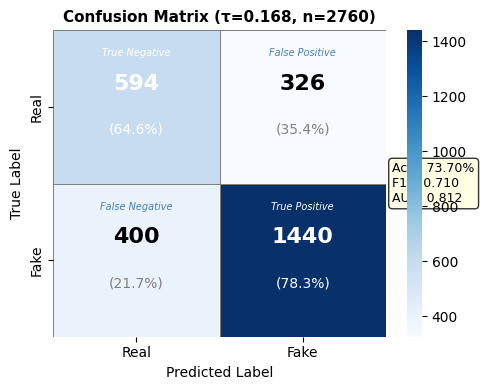

Saved: c:\Users\DPQUAI250101\Desktop\New folder (4)\confusion_matrix.png


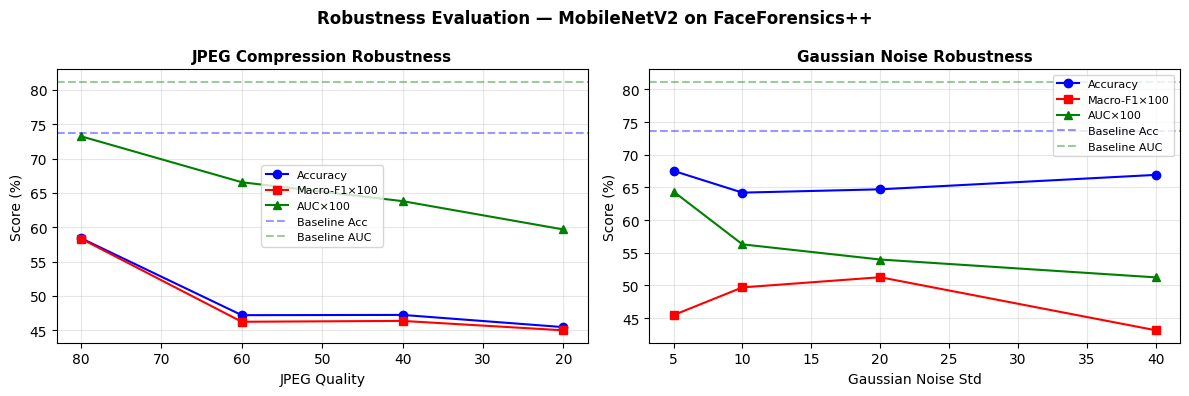

Saved: c:\Users\DPQUAI250101\Desktop\New folder (4)\robustness_plot.png
Saved: c:\Users\DPQUAI250101\Desktop\New folder (4)\error_analysis.png


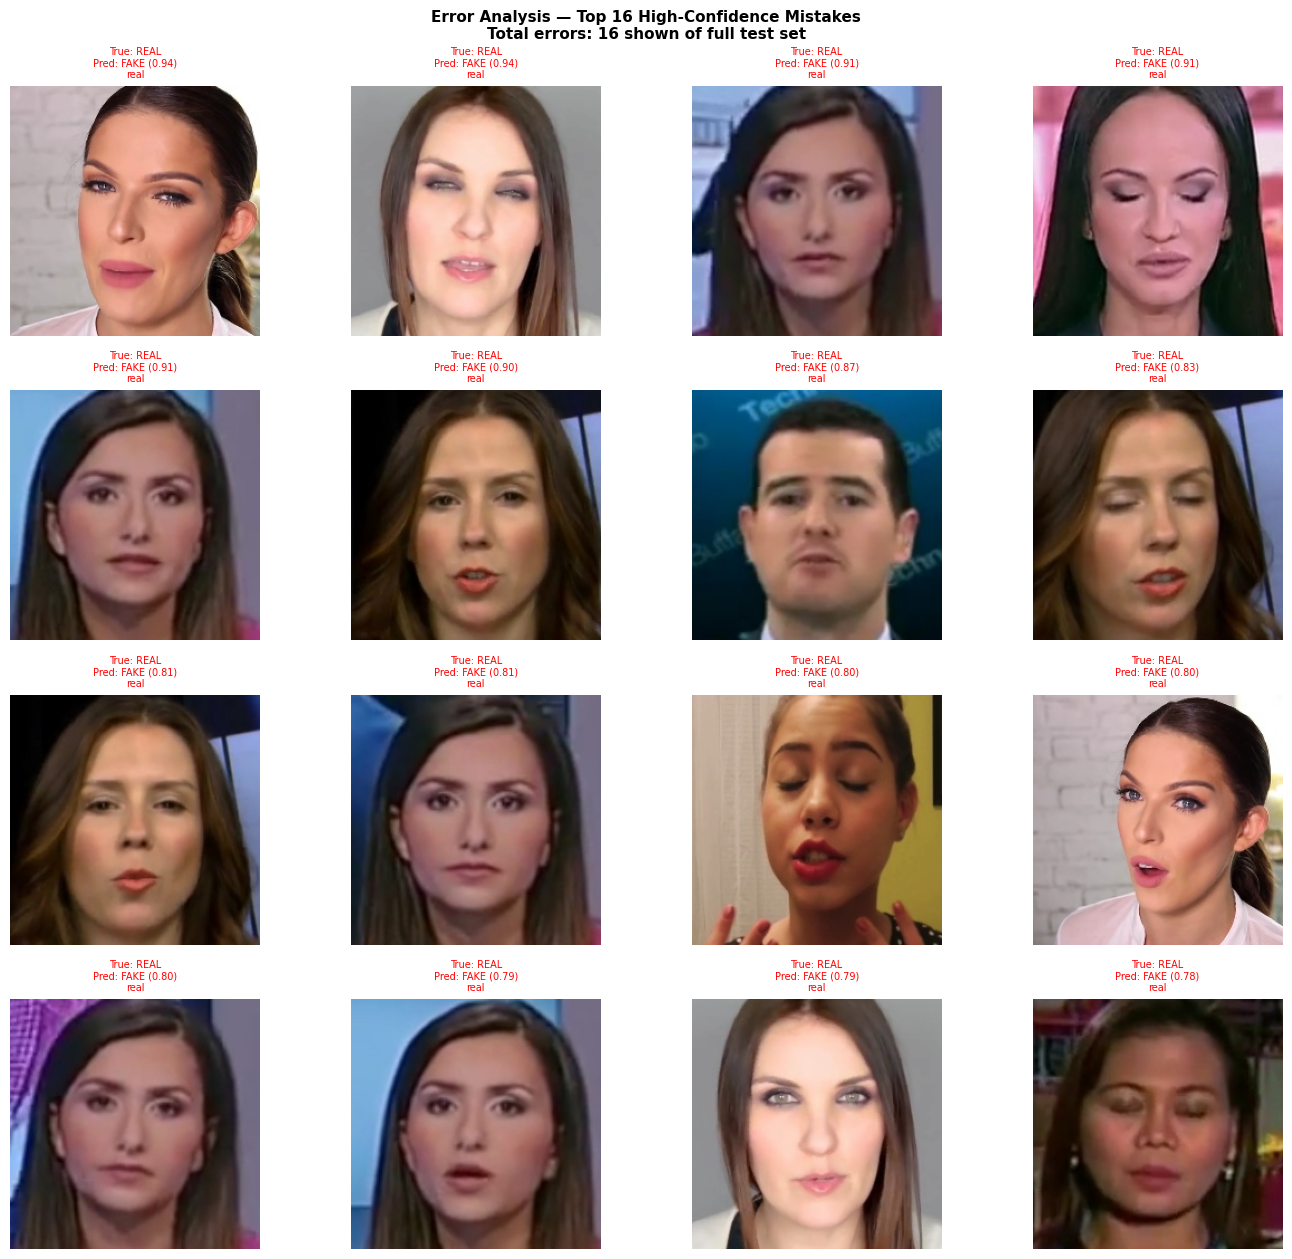


Error breakdown (top 16):
  Real predicted as Fake: 16
  Fake predicted as Real: 0
Saved: c:\Users\DPQUAI250101\Desktop\New folder (4)\gradcam.png


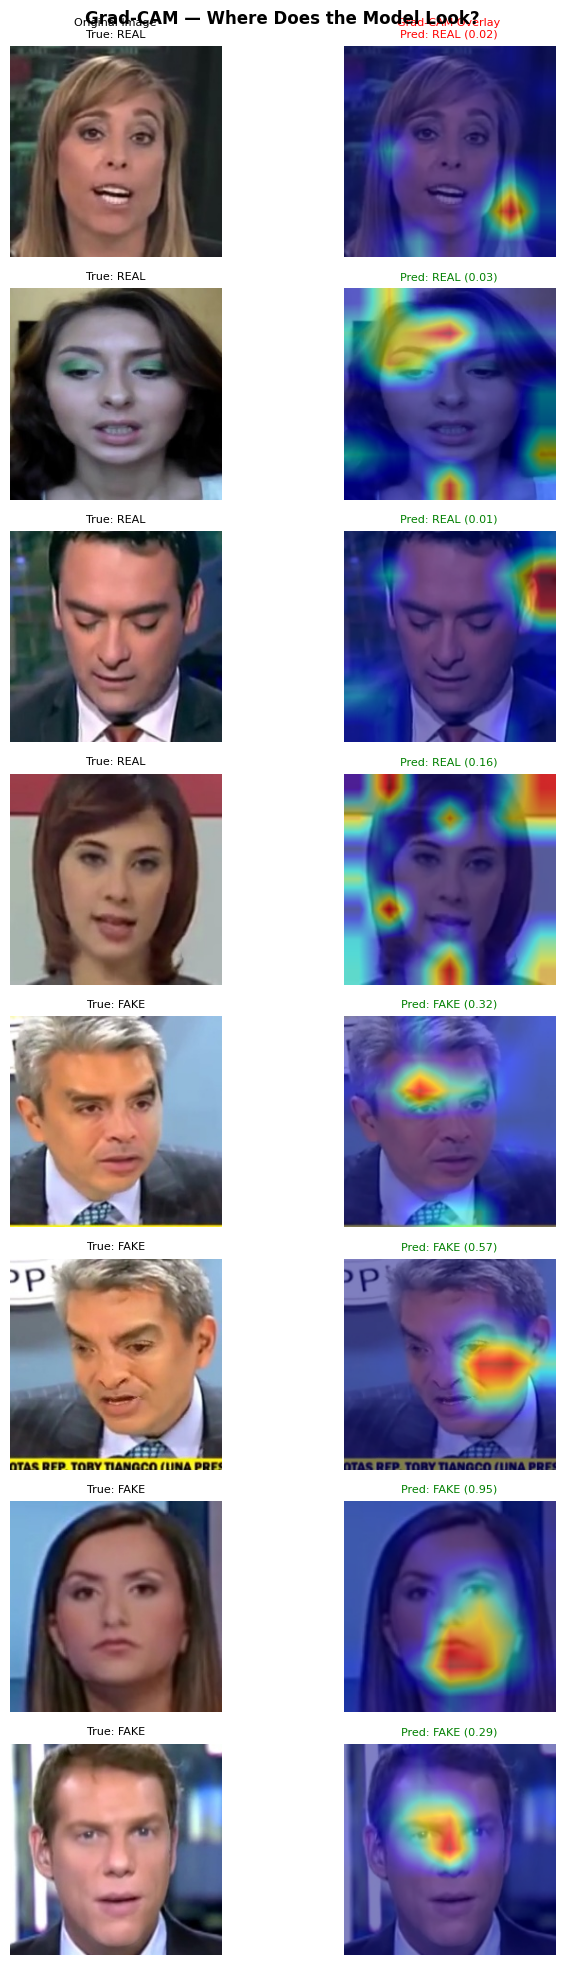

Saved: c:\Users\DPQUAI250101\Desktop\New folder (4)\ablation_study.png


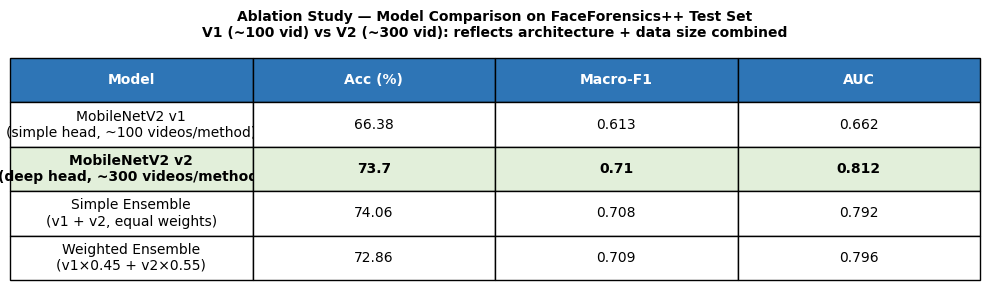


 All visualizations saved!


In [ ]:
# 7. RUN EVERYTHING

plot_confusion_matrix(
    y_test, pred_test, p_test, threshold,
    save_path=os.path.join(BASE_DIR, 'confusion_matrix.png')
)

# Robustness Plot
plot_robustness(
    os.path.join(BASE_DIR, 'robustness_results.csv'),
    save_path=os.path.join(BASE_DIR, 'robustness_plot.png')
)

# Error Analysis
plot_error_analysis(
    model, test_df, test_tf, threshold, n=16,
    save_path=os.path.join(BASE_DIR, 'error_analysis.png')
)

# Grad-CAM
plot_gradcam(
    model, test_df, test_tf, threshold,
    save_path=os.path.join(BASE_DIR, 'gradcam.png')
)


p1 = (p_test_v1 >= tune_threshold(y_val, p_val_v1)[0]).astype(int)
p2 = (p_test_v2 >= tune_threshold(y_val, p_val_v2)[0]).astype(int)
ablation_results = {
    'v1': {
        'acc': accuracy_score(y_test, p1),
        'f1':  f1_score(y_test, p1, average='macro'),
        'auc': roc_auc_score(y_test, p_test_v1),
    },
    'v2': {
        'acc': accuracy_score(y_test, p2),
        'f1':  f1_score(y_test, p2, average='macro'),
        'auc': roc_auc_score(y_test, p_test_v2),
    },
    'ens_simple': {
        'acc': accuracy_score(y_test, pred_ens),
        'f1':  f1_score(y_test, pred_ens, average='macro'),
        'auc': roc_auc_score(y_test, p_test_ens),
    },
    'ens_weighted': {
        'acc': test_acc_w,
        'f1':  test_f1_w,
        'auc': test_auc_w,
    },
    'w1': w1,
    'w2': w2,
}
plot_ablation_table(
    ablation_results,
    save_path=os.path.join(BASE_DIR, 'ablation_study.png')
)

print("\n All visualizations saved!")

In [ ]:
import os
import torch
import numpy as np
from PIL import Image
from torchvision import transforms

# 1. Save the model

save_path = os.path.join(BASE_DIR, 'deepfake_model_final.pth')
torch.save(model.state_dict(), save_path)
print(f'Model saved to: {save_path}')

# 2. Load the model from disk

def load_model(path):
    m = build_model()
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.eval()
    print(f'Model loaded from: {path}')
    return m

# To reload the model at any time:
# model = load_model(save_path)


# 3. Run inference on a single image

def predict_image(img_path, model, threshold=0.5):
    """
    Load an image from disk and predict whether it is real or fake.
    img_path  : path to the image file (jpg/png)
    model     : loaded model
    threshold : decision threshold (default 0.5, or use best_t_acc)
    """
    tf = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    img = Image.open(img_path).convert('RGB')
    x   = tf(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        out       = model(x)
        probs     = torch.softmax(out, dim=1)[0]
        prob_real = probs[0].item()
        prob_fake = probs[1].item()
        label     = 'FAKE' if prob_fake >= threshold else 'REAL'

    print(f'Image     : {os.path.basename(img_path)}')
    print(f'Prediction: {label}')
    print(f'prob_real = {prob_real:.4f}  |  prob_fake = {prob_fake:.4f}')
    print(f'threshold = {threshold:.3f}')
    return label, prob_real, prob_fake

# 4. Run on an image — change the path below

img_path = r"C:\Users\DPQUAI250101\Downloads\033_097_frame01.jpg"

if os.path.exists(img_path):
    predict_image(img_path, model, threshold=threshold)
else:
    print(f'Image not found: {img_path}')
    print('Update img_path to a valid image on your machine.')

Model saved to: c:\Users\DPQUAI250101\Desktop\New folder (4)\deepfake_model_final.pth
Image     : 033_097_frame01.jpg
Prediction: FAKE
prob_real = 0.1481  |  prob_fake = 0.8519
threshold = 0.168


In [ ]:
predict_image(img_path, model, threshold=threshold)


predict_image(img_path, model, threshold=0.5)          # neutral
predict_image(img_path, model, threshold=best_t_f1)    # optimized for F1

Image     : 033_097_frame01.jpg
Prediction: FAKE
prob_real = 0.1481  |  prob_fake = 0.8519
threshold = 0.168
Image     : 033_097_frame01.jpg
Prediction: FAKE
prob_real = 0.1481  |  prob_fake = 0.8519
threshold = 0.500
Image     : 033_097_frame01.jpg
Prediction: FAKE
prob_real = 0.1481  |  prob_fake = 0.8519
threshold = 0.168


('FAKE', 0.14813770353794098, 0.8518622517585754)